In [3]:
import csv
import pandas as pd
import torch
from pandas import read_csv

df_raw = pd.read_csv("train.csv")


In [4]:
df_raw.head()

,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X11,X12,X13,X14,X15,X16,X17,X18,X19,Y
0,256039,3600.0,a,7.37,b,a,b,62004.0,a,Feb-2009,...,3.50,6.0,0.0,5514.0,19.5,20.0,b,a,NaN,0
1,176486,12000.0,b,16.49,e,g,b,143000.0,a,Nov-2014,...,14.03,14.0,1.0,5808.0,75.4,36.0,a,a,1.0,0
2,392670,8500.0,b,11.49,a,b,b,27000.0,a,Jun-2010,...,0.89,12.0,0.0,449.0,2.0,22.0,b,a,NaN,1
3,46168,3725.0,a,10.99,a,l,a,14916.0,c,Nov-2015,...,32.42,14.0,0.0,6557.0,23.9,26.0,a,a,0.0,0
4,313821,28000.0,a,15.41,e,a,a,100000.0,b,Dec-2015,...,9.91,11.0,1.0,17499.0,53.2,29.0,b,a,0.0,1


In [5]:
import seaborn as sns
def plot_value(df, x, y = None):
    if y:
        sns.scatterplot(data=df,x=x, y=y)
    else:
        sns.histplot(data=df,x=x)

Count Y distribution
Y
0    254686
1     62138
Name: count, dtype: int64


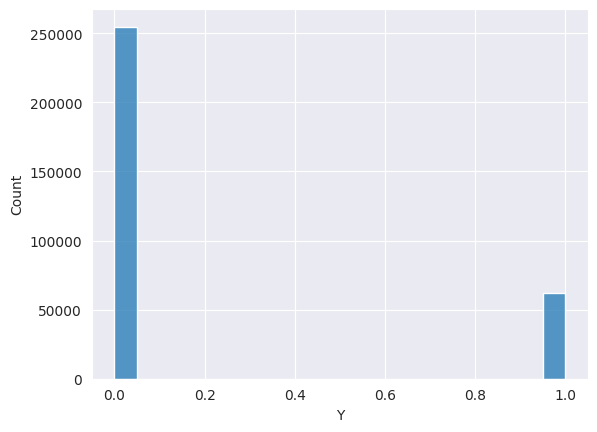

In [6]:
plot_value(df_raw,"Y")
print("Count Y distribution")
print(df_raw['Y'].value_counts())


30416 missing rows
Missing values:
ID         0
X1         0
X2         0
X3         0
X4         0
X5         0
X6         0
X7         0
X8         0
X9         0
X10        0
X11        0
X12        0
X13        0
X14        0
X15      230
X16        0
X17        0
X18        0
X19    30230
Y          0
dtype: int64


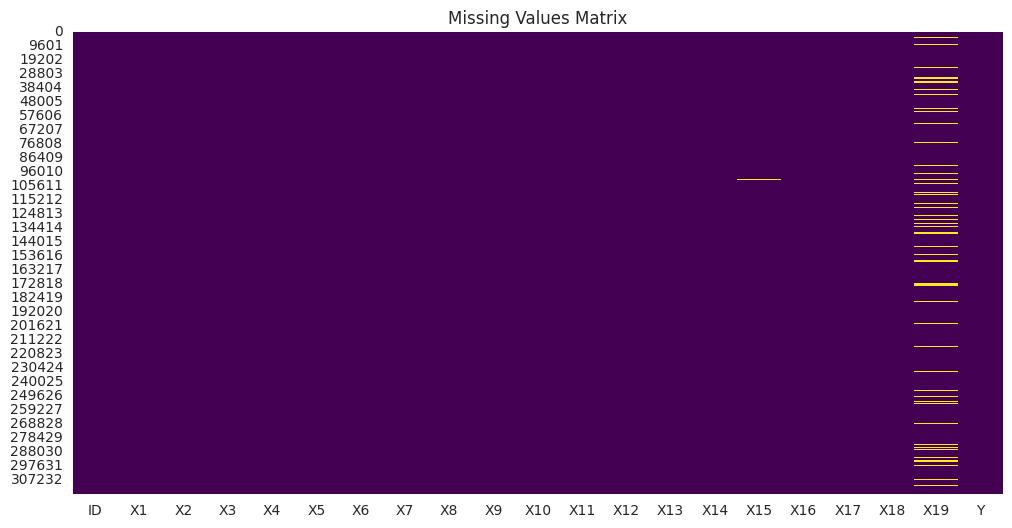

In [7]:
import missingno as msno
import matplotlib.pyplot as plt
# count missing rows

missing_rows = df_raw.isnull().any(axis=1).sum()
missing_count = df_raw.isnull().sum()
print(f"{missing_rows} missing rows")
print("Missing values:")
print(missing_count)
# Visualize the distribution of missing values using missingno matrix
plt.figure(figsize=(12, 6))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Matrix')
plt.show()



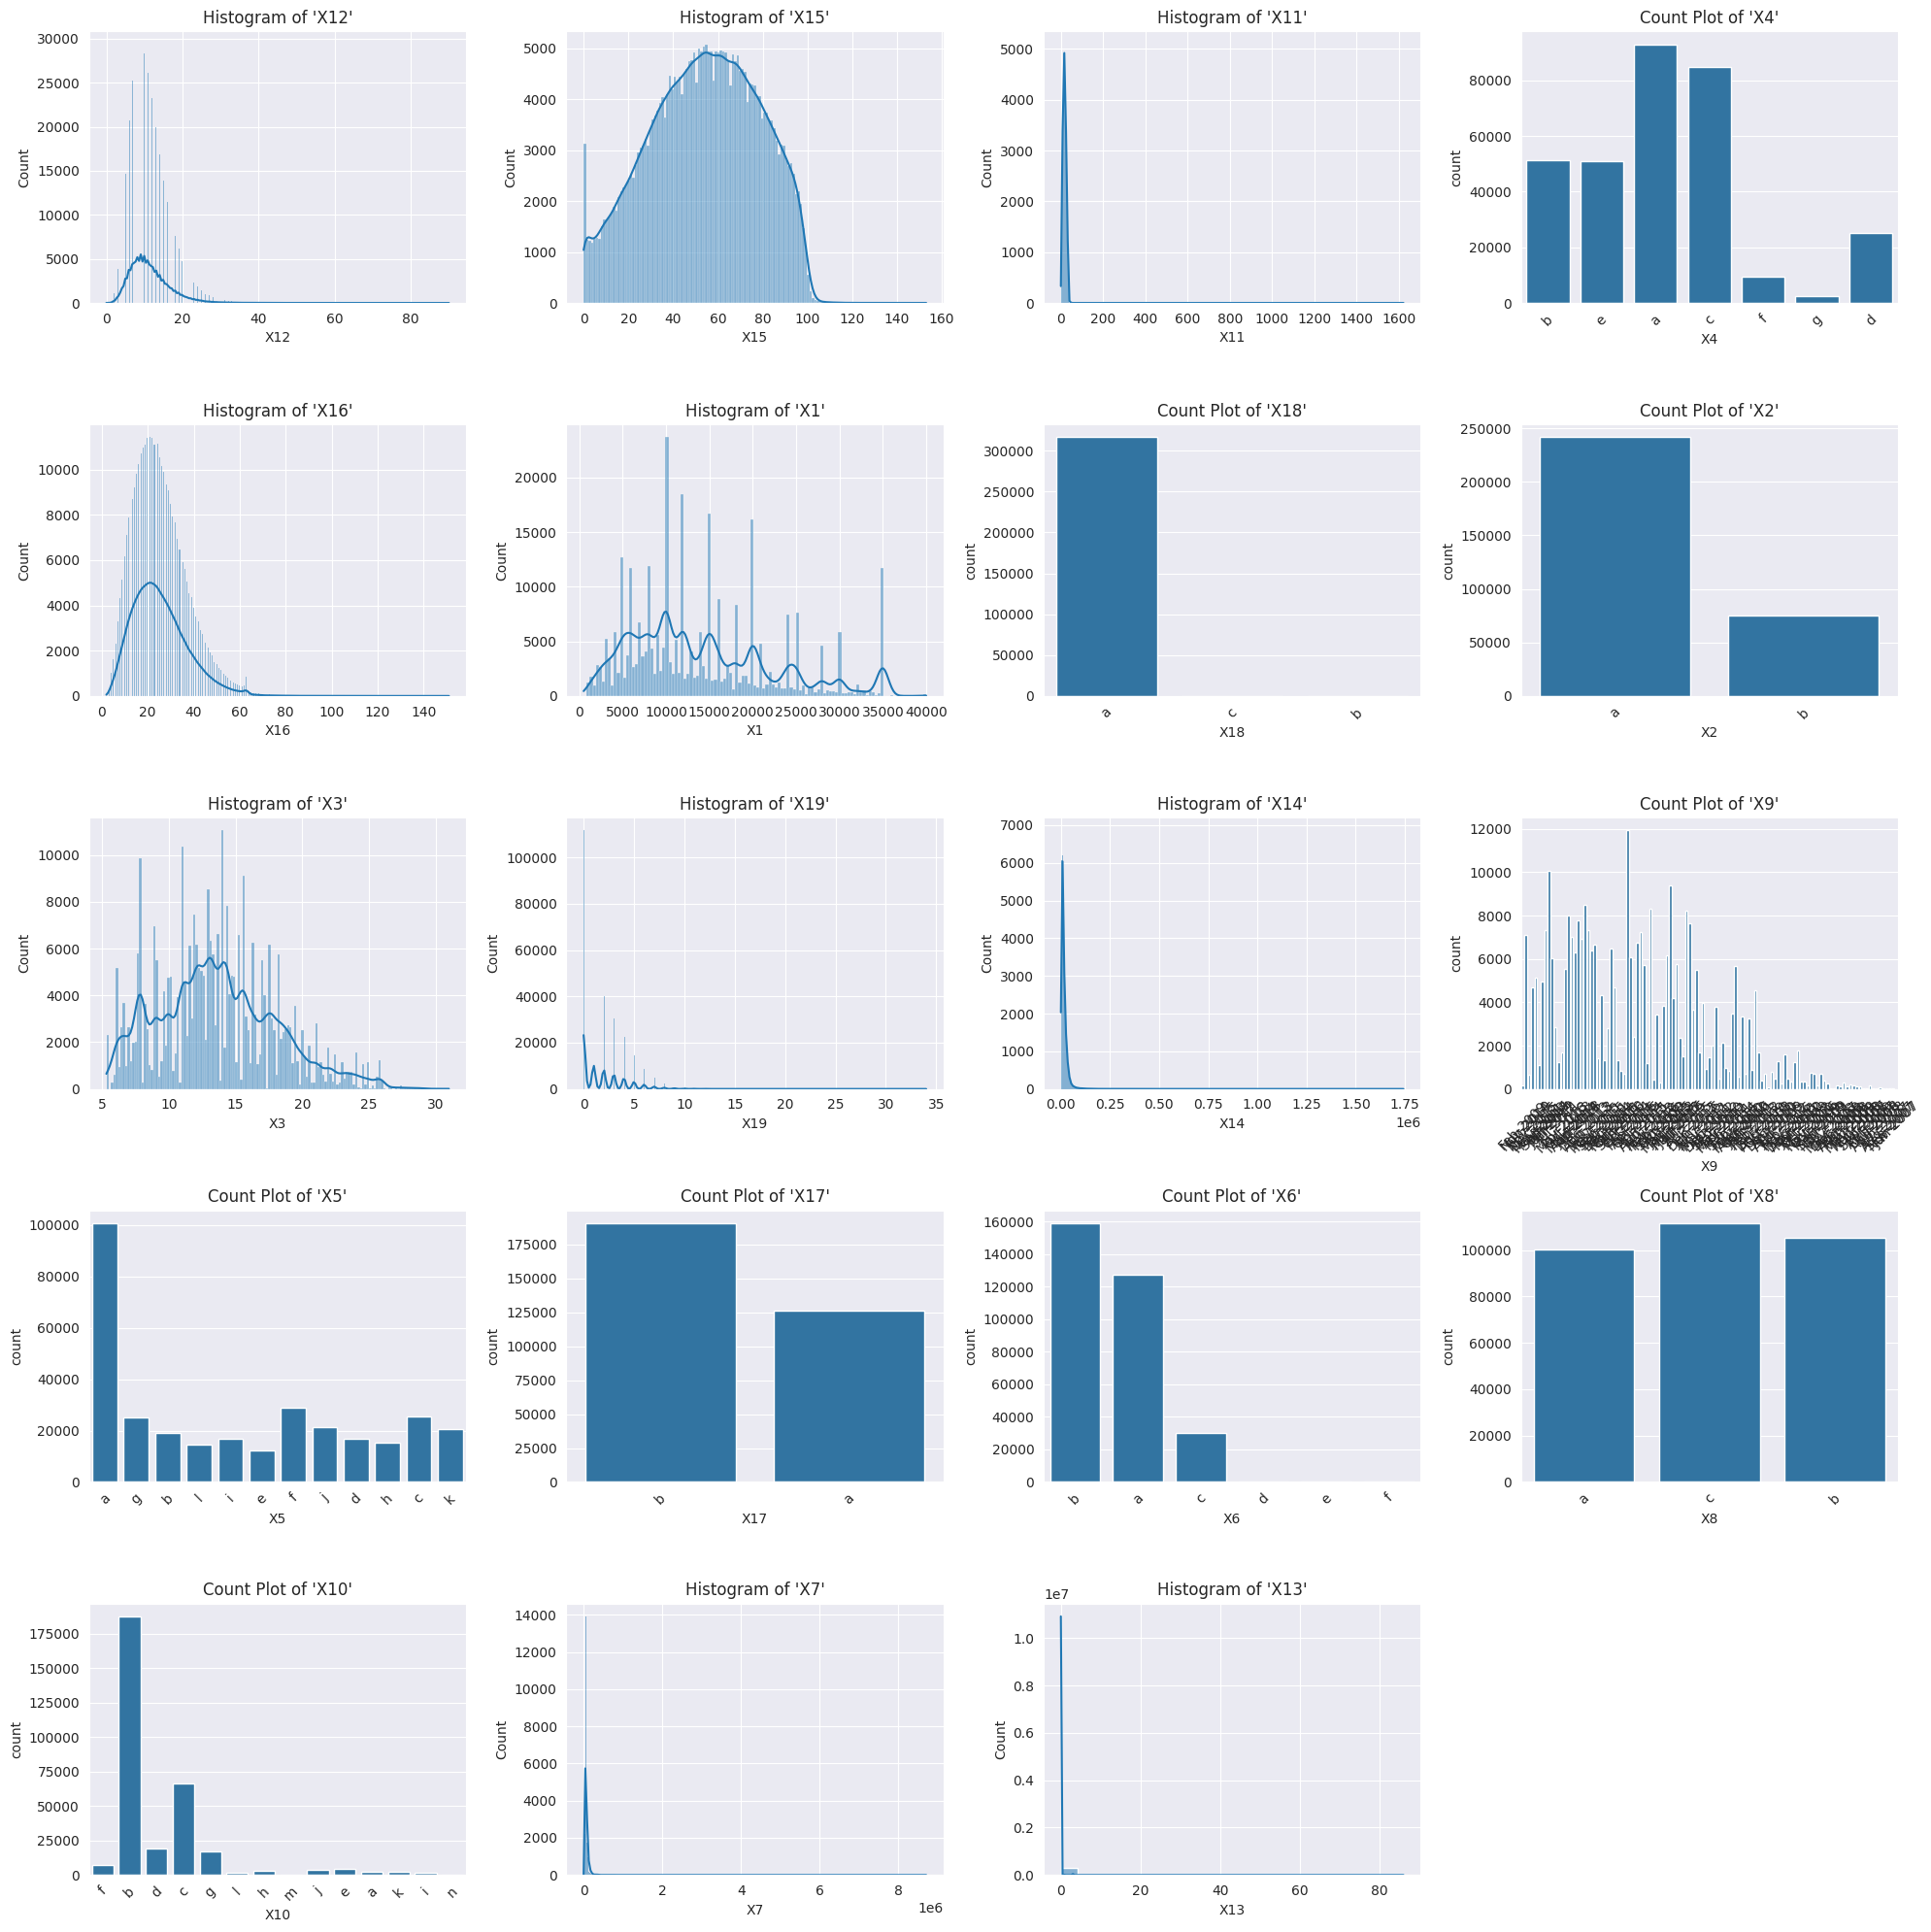

In [8]:
import matplotlib.pyplot as plt
import math
def plot_all_distributions(df,ignore =None):
    if not ignore:
        ignore = []
    ignore = set(ignore)
    columns = list(set(df.columns) - ignore)
    n = len(columns)
    n_cols = 4  # number of plots per row
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()  # Flatten in case it's a 2D array of axes

    for i,col in enumerate(columns):
        ax = axes[i]
        if pd.api.types.is_numeric_dtype(df[col]):
            sns.histplot(data=df, x=col, kde=True, ax=ax)

            ax.set_title(f"Histogram of '{col}'")
        else:
            sns.countplot(data=df, x=col, ax=ax)
            ax.set_title(f"Count Plot of '{col}'")
            ax.tick_params(axis='x', rotation=45)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


plot_all_distributions(df_raw,["ID","Y"])

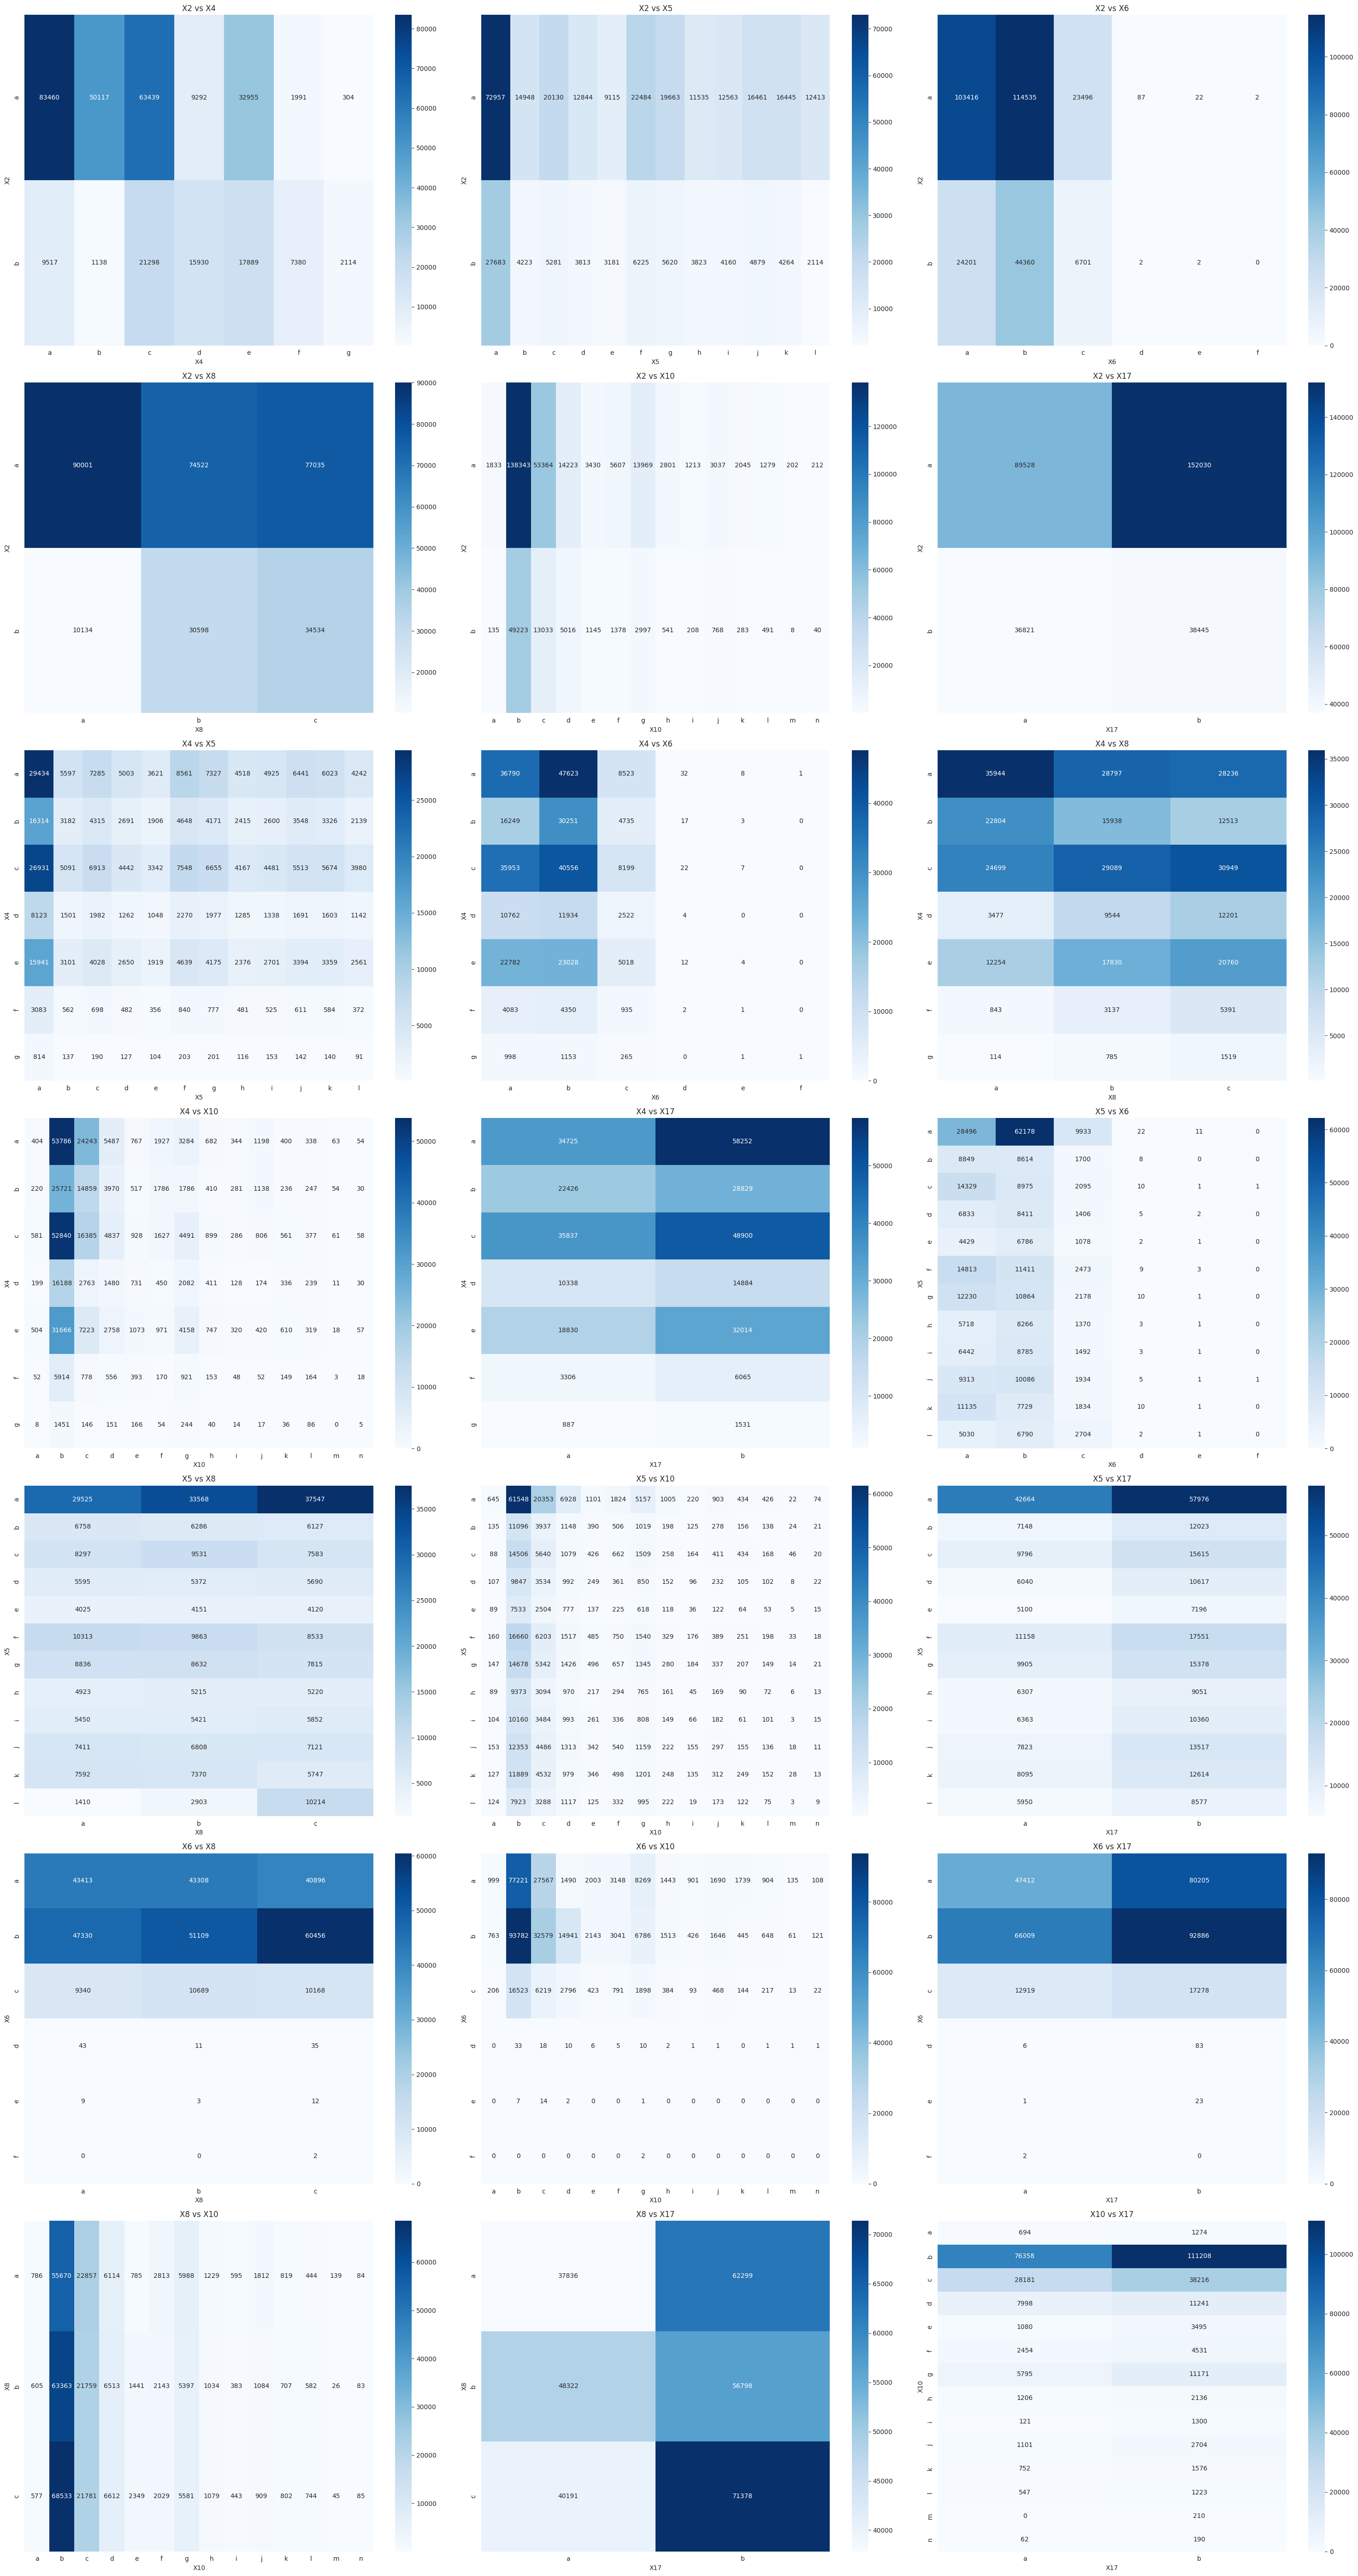

In [10]:
# examine some categorical data
import pandas as pd
import matplotlib.pyplot as plt
import math
from itertools import combinations
from typing import List

def plot_categorical_heatmaps(df: pd.DataFrame, cols: List[str]):
    SCALE=  2
    pairs = list(combinations(cols, 2))
    n = len(pairs)
    n_cols = 3  # plots per row
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5* SCALE * n_cols, 4*SCALE * n_rows))
    axes = axes.flatten()

    for i, (col1, col2) in enumerate(pairs):
        ax = axes[i]
        crosstab = pd.crosstab(df[col1], df[col2])
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f"{col1} vs {col2}")
        ax.set_xlabel(col2)
        ax.set_ylabel(col1)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_categorical_heatmaps(df_raw,["X2","X4","X5","X6","X8","X10","X17"])


In [13]:
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, MinMaxScaler,OrdinalEncoder
from sklearn.preprocessing import StandardScaler,RobustScaler

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, Binarizer
import pandas as pd

from sklearn.impute import SimpleImputer
import numpy as np


def clean_X6(X):
    X = X.copy()
    X6_include = set(["a", "b", "c"])
    X['X6'] = X['X6'].apply(lambda x: 'z' if x not in X6_include else x)
    return X

from datetime import datetime
def get_month(s):
    dt = datetime.strptime(s, "%b-%Y")
    return (dt.year - 1970) * 12 + (dt.month - 1)

def parse_date_X9(X):
    X = X.copy()
    X['X9'] = X['X9'].apply(lambda x: get_month(x))
    return X
from sklearn.pipeline import Pipeline
import numpy as np
# Define the column transformer (assuming OrdinalEncoder will be used on X6 later)

impute_and_scale_pipeline = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='mean')),
    ('scaler', RobustScaler())
])

# Create the full column transformer with proper handling of each column
ct = ColumnTransformer(
    transformers=[
        # Columns that need imputation and robust scaling
        ('impute_and_scale', impute_and_scale_pipeline, ['X15', 'X19']),

        # Binary values
        ('binarizer', Binarizer(), ['X13']),

        # Columns that only need robust scaling (no imputation needed)
        ('robust', RobustScaler(), ['X1', 'X3', 'X14']),

        # Min-max scaling for date column
        ('minmax', MinMaxScaler(), ['X9']),

        # Standard scaling
        ('standard', StandardScaler(), ["X7", "X11", "X12", "X16"]),

        # Ordinal encoding for categorical columns with order
        ('ordinal', OrdinalEncoder(), ['X17', "X2"]),

        ('drop_columns', 'drop', ["X18"]),

        # One-hot encoding for categorical columns with no inherent order
        ('onehot', OneHotEncoder(handle_unknown='ignore'), ['X4', 'X5', 'X6', 'X8', 'X10'])
    ],
    # Keep any columns not explicitly listed in transformers
    #remainder='drop'  # You can change to 'passthrough' if you want to keep other columns
)

# Combine everything into a pipeline
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('x6_cleaner', FunctionTransformer(clean_X6)),
    ('x9_parser', FunctionTransformer(parse_date_X9)),
    ('preprocess', ct)
])

In [17]:
ID = df_raw['ID']
Y = df_raw['Y']
df_raw_features = df_raw.drop(["Y","ID"],axis=1)
df_transformed_features = pipeline.fit_transform(df_raw_features)
df_transformed = pd.concat([ID, pd.DataFrame(df_transformed_features),Y], axis=1)
df_transformed.to_csv("transformedtrain.csv")


df_test = pd.read_csv("test.csv")
TEST_ID = df_test['ID']
df_raw_test_features = df_test.drop(["ID"],axis=1)
df_transformed_test_features = pipeline.transform(df_raw_test_features)
df_transformed_train = pd.concat([TEST_ID, pd.DataFrame(df_transformed_test_features)], axis=1)
df_transformed.to_csv("transformedtest.csv")
